![](http://)**Detecting Pneumonia in X-Ray Images**

Using data from http://www.cell.com/cell/fulltext/S0092-8674(18)30154-5

In [ ]:
!pip install keras-preprocessing

In [ ]:
import os
from glob import glob
import matplotlib.pyplot as plt
import random
import cv2
import pandas as pd
import numpy as np
import matplotlib.gridspec as gridspec
import seaborn as sns
import zlib
import itertools
import sklearn
import itertools
import scipy
import skimage
from skimage.transform import resize
import csv
from tqdm import tqdm
from sklearn import model_selection
from sklearn.model_selection import train_test_split, learning_curve,KFold,cross_val_score,StratifiedKFold
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix
import keras
from keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D, Lambda, MaxPool2D, BatchNormalization
from keras.utils import to_categorical
from keras_preprocessing.image import ImageDataGenerator
from keras import models, layers, optimizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.utils import class_weight
from keras.optimizers import SGD, RMSprop, Adam, Adagrad, Adadelta, RMSprop
from keras.models import Sequential, model_from_json
import tensorflow as tf
from tensorflow.keras.layers import Input
from keras.layers import Activation,Dense, Dropout, Flatten, Conv2D, MaxPool2D,MaxPooling2D,AveragePooling2D, BatchNormalization
from keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
from keras import backend as K
from keras.applications.vgg16 import VGG16
from keras.models import Model
from keras.applications.inception_v3 import InceptionV3
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from keras.callbacks import Callback

#from keras.applications.mobilenet import MobileNet
#from sklearn.metrics import roc_auc_score
#from sklearn.metrics import roc_curve
#from sklearn.metrics import auc
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

![](https://i.imgur.com/jZqpV51.png)

Figure S6. Illustrative Examples of Chest X-Rays in Patients with Pneumonia, Related to Figure 6
The normal chest X-ray (left panel) depicts clear lungs without any areas of abnormal opacification in the image. Bacterial pneumonia (middle) typically exhibits a focal lobar consolidation, in this case in the right upper lobe (white arrows), whereas viral pneumonia (right) manifests with a more diffuse ‘‘interstitial’’ pattern in both lungs.
http://www.cell.com/cell/fulltext/S0092-8674(18)30154-5



*Step 1: Import Modules*

*Step 2: Load Data*

In [ ]:
!pip install kaggle

In [ ]:
!mkdir -p ~/.kaggle
!echo "KGAT_3b8294c7d0c5cfa6ac6e7ae158394ff1" > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

# 3. Download the pneumonia dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# 4. Unzip it into your working folder
!unzip -q chest-xray-pneumonia.zip -d /content/chest_ray

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:29<00:00, 84.3MB/s]



In [ ]:
train_dir = "chest_ray/chest_xray/train/"
test_dir =  "chest_ray/chest_xray/test/"
def get_data(folder):
    X = []
    y = []
    for folderName in os.listdir(folder):
        if not folderName.startswith('.'):
            if folderName in ['NORMAL']:
                label = 0
            elif folderName in ['PNEUMONIA']:
                label = 1
            else:
                label = 2
            for image_filename in tqdm(os.listdir(folder + folderName)):
                img_file = cv2.imread(folder + folderName + '/' + image_filename)
                if img_file is not None:
                    img_file = skimage.transform.resize(img_file, (150, 150, 3))
                    #img_file = scipy.misc.imresize(arr=img_file, size=(150, 150, 3))
                    img_arr = np.asarray(img_file)
                    X.append(img_arr)
                    y.append(label)
    X = np.asarray(X)
    y = np.asarray(y)
    return X,y
X_train, y_train = get_data(train_dir)
X_test, y_test= get_data(test_dir)
# Encode labels to hot vectors (ex : 2 -> [0,0,1,0,0,0,0,0,0,0])
from keras.utils import to_categorical
y_trainHot = to_categorical(y_train, num_classes = 2)
y_testHot = to_categorical(y_test, num_classes = 2)

100%|██████████| 234/234 [02:15<00:00,  1.73it/s]


# New section

*Step 3: Vizualize Data*

The min/max pixel values are already scaled between 0 and 1

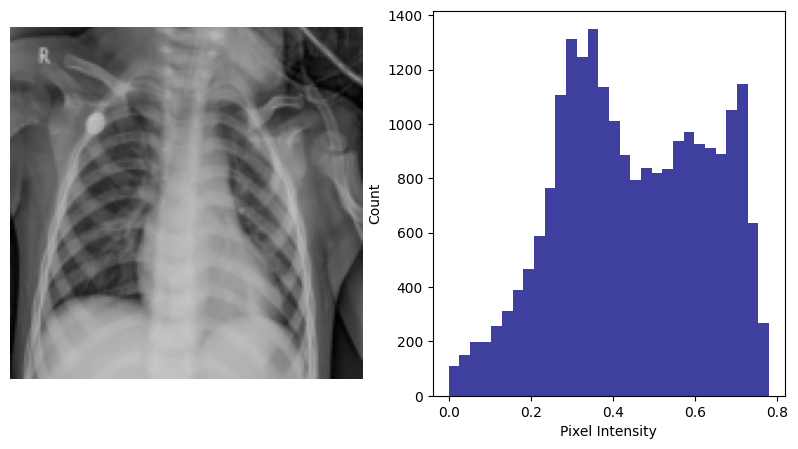

In [ ]:
def plotHistogram(a):
    """
    Plot histogram of RGB Pixel Intensities
    """
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.imshow(a)
    plt.axis('off')
    histo = plt.subplot(1,2,2)
    histo.set_ylabel('Count')
    histo.set_xlabel('Pixel Intensity')
    n_bins = 30
    plt.hist(a[:,:,0].flatten(), bins= n_bins, lw = 0, color='r', alpha=0.5);
    plt.hist(a[:,:,1].flatten(), bins= n_bins, lw = 0, color='g', alpha=0.5);
    plt.hist(a[:,:,2].flatten(), bins= n_bins, lw = 0, color='b', alpha=0.5);
plotHistogram(X_train[1])

The massive hill between 0.5 and 0.8 shows that the vast majority of the image consists of mid-to-bright gray values, which represent the lung tissue, ribs, and heart structures.

3 X-Rays from category "No Pneumonia"

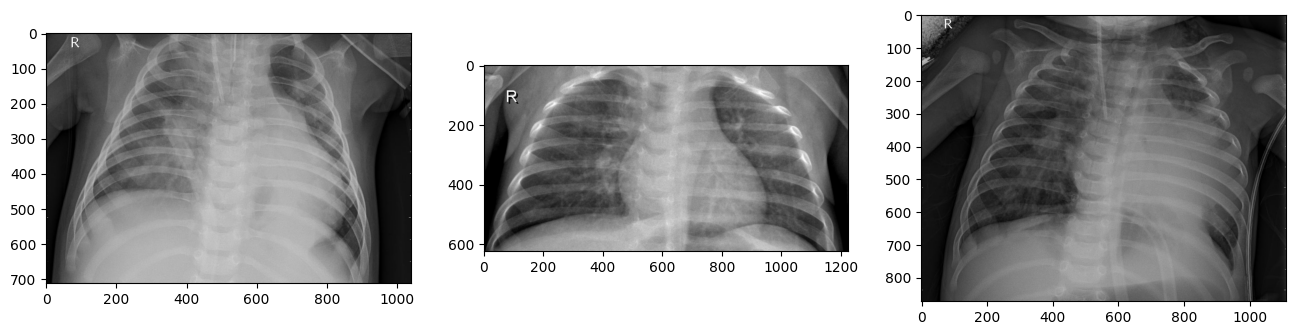

In [ ]:
multipleImages = glob("/content/chest_ray/chest_xray/train/PNEUMONIA/*.jpeg")
def plotThreeImages(images):
    r = random.sample(images, 3)
    plt.figure(figsize=(16,16))
    plt.subplot(131)
    plt.imshow(cv2.imread(r[0]))
    plt.subplot(132)
    plt.imshow(cv2.imread(r[1]))
    plt.subplot(133)
    plt.imshow(cv2.imread(r[2]));
plotThreeImages(multipleImages)

20 images from category "No Pneumonia"

No Pneumonia


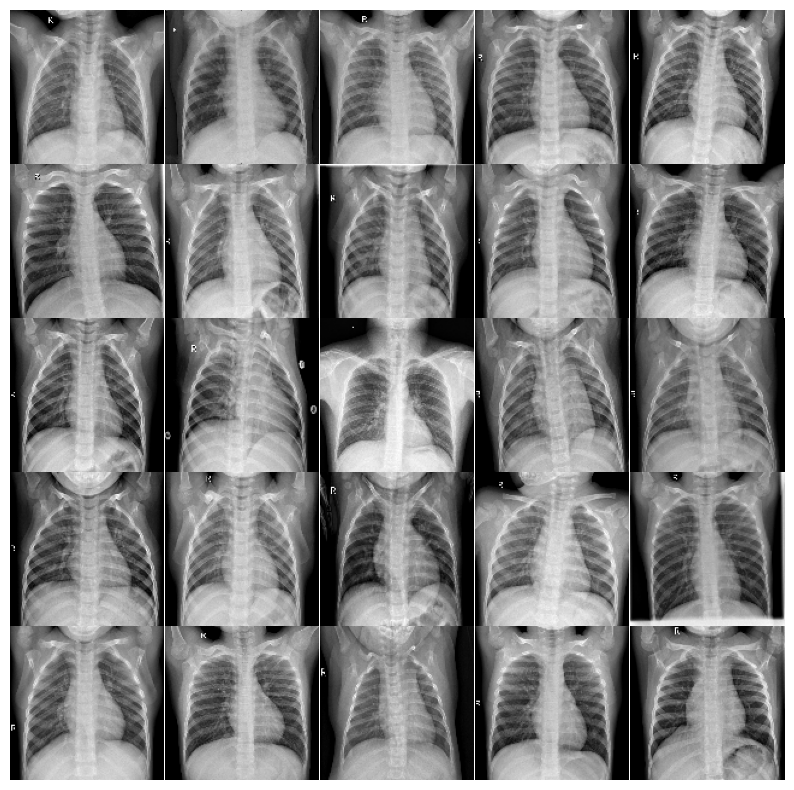

In [ ]:
print("No Pneumonia")
multipleImages = glob('/content/chest_ray/chest_xray/train/NORMAL/*')
i_ = 0
plt.rcParams['figure.figsize'] = (10.0, 10.0)
plt.subplots_adjust(wspace=0, hspace=0)
for l in multipleImages[:25]:
    im = cv2.imread(l)
    im = cv2.resize(im, (128, 128))
    plt.subplot(5, 5, i_+1) #.set_title(l)
    plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); plt.axis('off')
    i_ += 1

20 images from category "Yes Pneumonia"

Yes Pneumonia


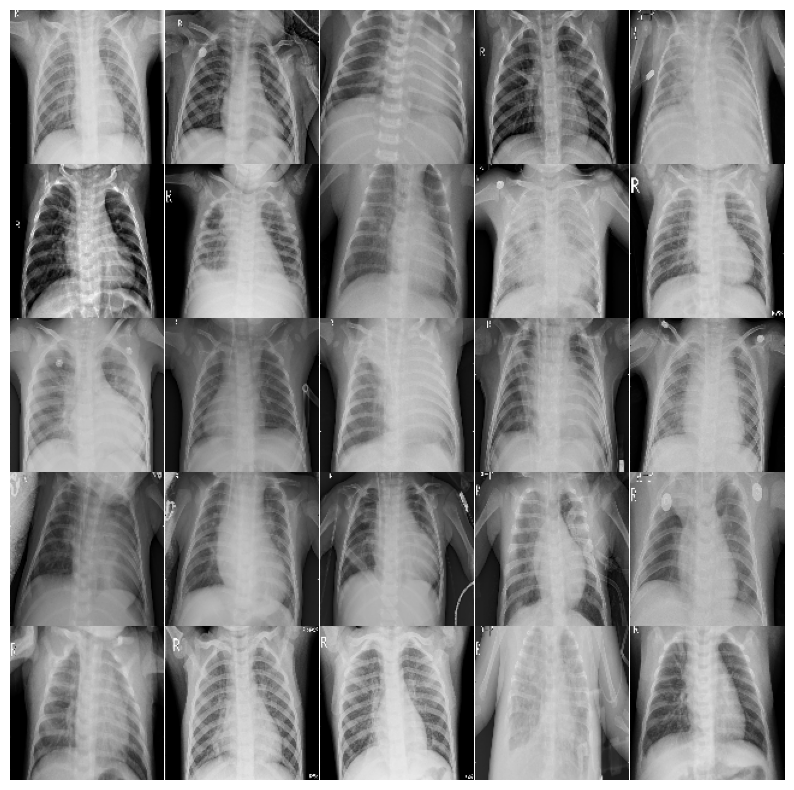

In [ ]:
print("Yes Pneumonia")
multipleImages = glob('/content/chest_ray/chest_xray/train/PNEUMONIA/*')
i_ = 0
plt.rcParams['figure.figsize'] = (10.0, 10.0)
plt.subplots_adjust(wspace=0, hspace=0)
for l in multipleImages[:25]:
    im = cv2.imread(l)
    im = cv2.resize(im, (128, 128))
    plt.subplot(5, 5, i_+1) #.set_title(l)
    plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); plt.axis('off')
    i_ += 1

In [ ]:
y_train

array([1, 1, 1, ..., 0, 0, 0])

Class Imbalance

{0: 'No Pneumonia', 1: 'Yes Pneumonia'}


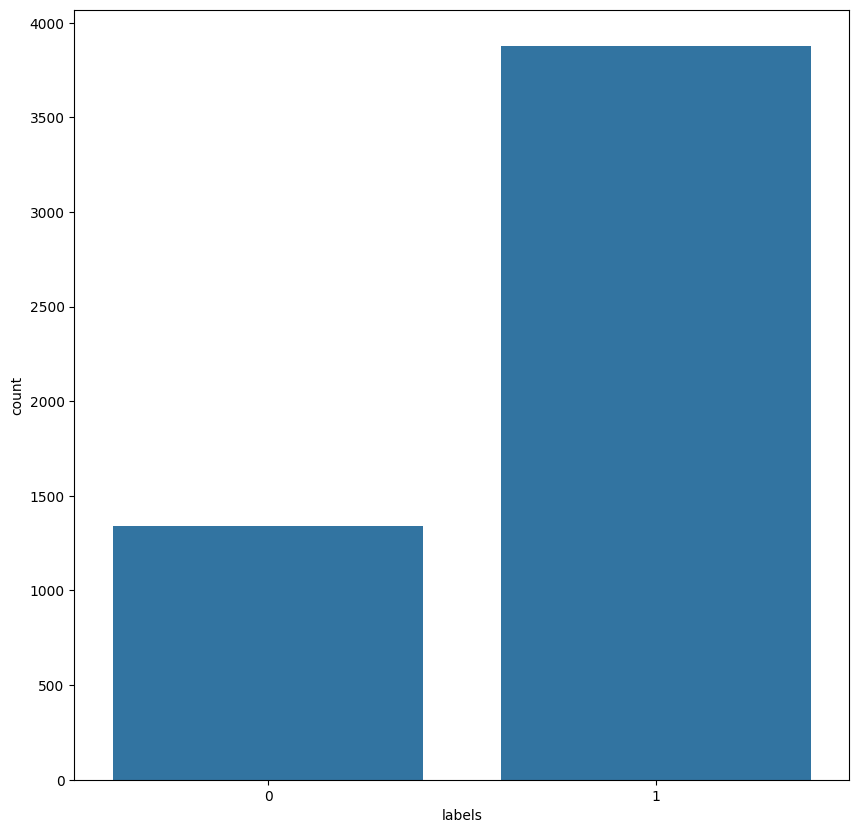

In [ ]:
map_characters = {0: 'No Pneumonia', 1: 'Yes Pneumonia'}
dict_characters=map_characters
import seaborn as sns
df = pd.DataFrame()
df["labels"]=y_train
lab = df['labels']
dist = lab.value_counts()
sns.countplot(x=lab)
print(dict_characters)

*Step 4: Define Helper Functions*

In [ ]:
class MetricsCheckpoint(Callback):
    def __init__(self, savepath):
        super(MetricsCheckpoint, self).__init__()
        self.savepath = savepath
        self.history = {}
    def on_epoch_end(self, epoch, logs=None):
        for k, v in logs.items():
            self.history.setdefault(k, []).append(v)
        np.save(self.savepath, self.history)          # ✅ save as logs.npy

def plotKerasLearningCurve():
    plt.figure(figsize=(10,5))
    metrics = np.load('logs.npy', allow_pickle=True)[()] # ✅ allow_pickle
    filt = ['accuracy']                                   # ✅ renamed
    for k in filter(lambda x: np.any([kk in x for kk in filt]), metrics.keys()):
        l = np.array(metrics[k])
        plt.plot(l, c='r' if 'val' not in k else 'b',
                 label='val' if 'val' in k else 'train')
        x = np.argmin(l) if 'loss' in k else np.argmax(l)
        y = l[x]
        plt.scatter(x, y, lw=0, alpha=0.25, s=100,
                    c='r' if 'val' not in k else 'b')
        plt.text(x, y, '{} = {:.4f}'.format(x, y), size='15',
                 color='r' if 'val' not in k else 'b')
    plt.legend(loc=4)
    plt.axis([0, None, None, None])
    plt.grid()
    plt.xlabel('Number of epochs')
    plt.ylabel('Accuracy')

def plot_learning_curve(history):
    plt.figure(figsize=(8,8))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'])              # ✅ renamed
    plt.plot(history.history['val_accuracy'])          # ✅ renamed
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.savefig('./accuracy_curve.png')
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.savefig('./loss_curve.png')

*Step 5: Evaluate Classification Models*

Transfer learning w/ VGG16 Convolutional Network

In [ ]:
from sklearn.utils import class_weight

In [ ]:
map_characters1 = {0: 'No Pneumonia', 1: 'Yes Pneumonia'}
raw_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight1 = dict(enumerate(raw_weights))

# Let Keras download the weights directly via 'imagenet'
pretrained_model_1 = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
pretrained_model_2 = InceptionV3(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

optimizer1 = keras.optimizers.RMSprop(learning_rate=0.0001)

def pretrainedNetwork(xtrain, ytrain, xtest, ytest, pretrainedmodel, classweight, numclasses, numepochs, optimizer, labels):
    base_model = pretrainedmodel

    # 1. NEW: Define safe medical data augmentation layers
    data_augmentation = keras.Sequential([
        keras.layers.RandomRotation(0.03, fill_mode='constant', fill_value=0.0),      # Max ~10 degree rotation
        keras.layers.RandomZoom(0.1, fill_mode='constant', fill_value=0.0),          # Max 10% zoom in/out
        keras.layers.RandomTranslation(0.1, 0.1, fill_mode='constant', fill_value=0.0) # Max 10% horizontal/vertical shift
    ], name="medical_data_augmentation")

    # 2. NEW: Establish the input entry point and link augmentation
    inputs = Input(shape=(150, 150, 3))
    x = data_augmentation(inputs)  # Randomly warps images ONLY during model.fit()

    # 3. FIXED: Pass the augmented outputs into the pre-trained feature extractor
    x = base_model(x, training=False) # Keeps underlying backbone parameters and normalization locked

    # 4. Add top classification layer
    x = Flatten()(x)
    predictions = Dense(numclasses, activation='softmax')(x)

    # Reconstruct the entire model pipeline from our new input layer
    model = Model(inputs=inputs, outputs=predictions)

    # Freeze the backbone layers so their parameters don't change
    for layer in base_model.layers:
        layer.trainable = False

    model.compile(loss='categorical_crossentropy',
                  optimizer=optimizer,
                  metrics=['accuracy'])

    # FIXED: Changed 'val_acc' to 'val_loss' for modern Keras compatibility
    callbacks_list = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, verbose=1)]

    model.summary()

    # Train the model
    history = model.fit(xtrain, ytrain,
                        epochs=numepochs,
                        class_weight=classweight,
                        validation_data=(xtest, ytest),
                        verbose=1,
                        callbacks=callbacks_list)

    # Evaluate model
    score = model.evaluate(xtest, ytest, verbose=0)
    print('\nKeras CNN - Test accuracy:', score[1], '\n')

    # Predictions & Matrix Metrics
    y_pred = model.predict(xtest)

    # FIXED: Fixed the indexing for the true labels presentation
    print('\nClassification Report:\n',
          sklearn.metrics.classification_report(np.argmax(ytest, axis=1),
                                                np.argmax(y_pred, axis=1),
                                                target_names=list(labels.values())))

    return model,history

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Transfer learning w/ InceptionV3 Convolutional Network

*Step 6: Evaluate Undersampling Strategy*

The goal is to get rid of the class imbalance issues.  Oversampling with data augmentation (e.g. [SMOTE](http://contrib.scikit-learn.org/imbalanced-learn/stable/over_sampling.html)) would be preferable to undersampling but undersampling is faster.

Class weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


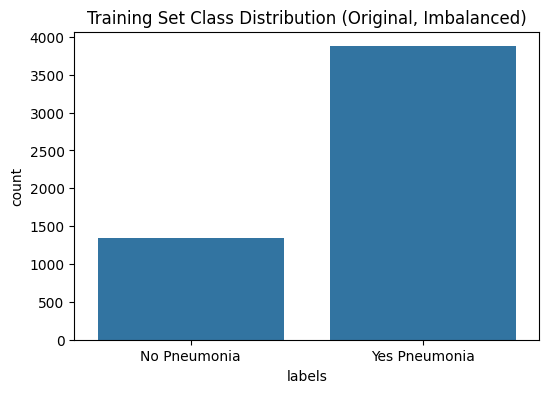

labels
1    3875
0    1341
Name: count, dtype: int64


In [ ]:
# Deal with imbalanced class sizes using class weights (no resampling needed)


map_characters1 = {0: 'No Pneumonia', 1: 'Yes Pneumonia'}

raw_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight1 = dict(enumerate(raw_weights))
print("Class weights:", class_weight1)

# Encode labels to one-hot vectors — data itself stays untouched, full size
Y_trainHot = to_categorical(y_train, num_classes=2)
Y_testHot = to_categorical(y_test, num_classes=2)

# Plot the TRUE label distribution (no resampling applied)
dfTrain = pd.DataFrame({"labels": y_train})
plt.figure(figsize=(6, 4))
sns.countplot(x="labels", data=dfTrain)
plt.xticks(ticks=[0, 1], labels=['No Pneumonia', 'Yes Pneumonia'])
plt.title("Training Set Class Distribution (Original, Imbalanced)")
plt.show()

print(dfTrain["labels"].value_counts())

*Step 7: Evaluate Final Model*

Transfer learning w/ VGG16 Convolutional Network

In [ ]:
model, history = pretrainedNetwork(
    xtrain=X_train,
    ytrain=Y_trainHot,
    xtest=X_test,
    ytest=Y_testHot,
    pretrainedmodel=pretrained_model_1,
    classweight=class_weight1,
    numclasses=2,
    numepochs=30,
    optimizer=optimizer1,        # ← add this
    labels=map_characters1
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ medical_data_augmentation       │ (None, 150, 150, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │        16,386 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,731,074 (56.19 MB)

 Trainable params: 16,386 (64.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/30
142/163 ━━━━━━━━━━━━━━━━━━━━ 2:32 7s/step - accuracy: 0.7716 - loss: 0.5124

In [ ]:
# ── Get predictions on the test set ─────────────────────────
y_pred_probs = model.predict(X_test)              # shape (N, 2) softmax outputs
y_pred_labels = np.argmax(y_pred_probs, axis=1)    # 0 = No Pneumonia, 1 = Yes Pneumonia
y_true_labels = y_test                              # already plain 0/1 from your earlier cells
y_pred_pneumonia_prob = y_pred_probs[:, 1]          # probability of class "Yes Pneumonia"


# ── Confusion Matrix ─────────────────────────────────────────
cm = confusion_matrix(y_true_labels, y_pred_labels)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)
print(f"\nTrue Negatives  (correctly No Pneumonia): {tn}")
print(f"False Positives (false alarm):              {fp}")
print(f"False Negatives (missed Pneumonia):         {fn}  ⚠ most critical")
print(f"True Positives  (correctly caught):         {tp}")

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Pneumonia', 'Yes Pneumonia'],
            yticklabels=['No Pneumonia', 'Yes Pneumonia'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100)
plt.show()


# ── Sensitivity, Specificity, Accuracy, F1 ──────────────────
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
f1 = 2 * (precision * sensitivity) / (precision + sensitivity)

print(f"\nAccuracy:    {accuracy:.4f}")
print(f"Sensitivity: {sensitivity:.4f}  (catches {sensitivity*100:.1f}% of real Pneumonia cases)")
print(f"Specificity: {specificity:.4f}  (correctly clears {specificity*100:.1f}% of healthy patients)")
print(f"Precision:   {precision:.4f}")
print(f"F1 Score:    {f1:.4f}")


# ── Full classification report ──────────────────────────────
print("\nClassification Report:")
print(classification_report(y_true_labels, y_pred_labels,
                            target_names=['No Pneumonia', 'Yes Pneumonia']))


# ── ROC Curve + AUC ──────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_true_labels, y_pred_pneumonia_prob)
auc_score = roc_auc_score(y_true_labels, y_pred_pneumonia_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#1D9E75', linewidth=2, label=f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random guess (AUC = 0.5)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve — Pneumonia Detection')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=100)
plt.show()

print(f"\nAUC-ROC Score: {auc_score:.4f}")

Transfer learning w/ InceptionV3 Convolutional Network

 We were able to detect pneumonia in x-ray images with an accuracy rate of approximately 85%.  Great!

To Do: (1) Add data augmentation; (2) Add ROC curve; (3)

In [ ]:
# ============================================================
# Learning curves — checks for overfitting
# Uses 'history' object returned by your pretrainedNetwork() call
# ============================================================

import matplotlib.pyplot as plt

# If your function returned just the model (not history),
# check what your function's `return` statement gave you.
# If it only returned `model`, you may need history from inside it instead —
# let me know if 'history' doesn't exist and I'll adjust.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy over epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=100)
plt.show()

In [ ]:
# ── STEP 1 (corrected): Skip augmentation layer — only keep Flatten + Dense ──
vgg_submodel = model.get_layer('vgg16')

flat_input = vgg_submodel.input
flat_vgg_output = vgg_submodel.output

# Only keep the classifier head layers (Flatten, Dense) — skip augmentation
extra_layers = [l for l in model.layers
                if l.name in ['flatten_6', 'dense_6']]
print("Layers after VGG16:", [l.name for l in extra_layers])

x = flat_vgg_output
for layer in extra_layers:
    x = layer(x)

flat_model = Model(inputs=flat_input, outputs=x)

# ── STEP 2: Grad-CAM model from the flat model ────────────────
grad_model = Model(
    inputs=flat_model.input,
    outputs=[flat_model.get_layer('block5_conv3').output, flat_model.output]
)

def make_gradcam_heatmap(img_array, pred_index=None):
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index)

In [ ]:
def overlay_gradcam(img, heatmap, alpha=0.4):
    img_uint8 = np.uint8(255 * img) if img.max() <= 1.0 else np.uint8(img)
    heatmap_resized = cv2.resize(heatmap, (img_uint8.shape[1], img_uint8.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(img_uint8, 1 - alpha, heatmap_colored, alpha, 0)


class_names = ['No Pneumonia', 'Yes Pneumonia']
indices = np.random.choice(len(X_test), 6, replace=False)

fig, axes = plt.subplots(2, 6, figsize=(18, 7))
fig.suptitle("Grad-CAM: Where the model looks when predicting", fontsize=14)

for col, idx in enumerate(indices):
    img = X_test[idx]
    img_batch = np.expand_dims(img.astype('float32'), axis=0)

    heatmap, pred_class = make_gradcam_heatmap(img_batch)
    overlaid = overlay_gradcam(img, heatmap)

    true_class = int(y_test[idx])
    correct = "✓" if pred_class == true_class else "✗"

    axes[0, col].imshow(img)
    axes[0, col].set_title(f"True: {class_names[true_class]}", fontsize=9)
    axes[0, col].axis('off')

    axes[1, col].imshow(overlaid)
    axes[1, col].set_title(f"{correct} Pred: {class_names[pred_class]}", fontsize=9,
                            color='green' if correct == "✓" else 'red')
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig('gradcam_examples.png', dpi=100)
plt.show()
print("Saved: gradcam_examples.png")


In [ ]:
# ============================================================
# Save everything so you NEVER have to retrain again
# Run this once, now, while your model/history/results are in memory
# ============================================================

import pickle
import json

# ── 1. Save the trained model itself (the big one — weights + architecture) ──
model.save('pneumonia_model.keras')
print("Saved: pneumonia_model.keras")

# ── 2. Save training history (for re-plotting learning curves later) ─────────
with open('training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)
print("Saved: training_history.pkl")

# ── 3. Save your evaluation metrics as a simple JSON (for your report) ───────
results_summary = {
    "accuracy": float(accuracy),
    "sensitivity": float(sensitivity),
    "specificity": float(specificity),
    "precision": float(precision),
    "f1_score": float(f1),
    "auc_roc": float(auc_score),
    "confusion_matrix": {
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp)
    }
}

with open('results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2)
print("Saved: results_summary.json")
print(json.dumps(results_summary, indent=2))

# ── 4. Confirm your image files already exist (from earlier cells) ───────────
import os
saved_images = ['confusion_matrix.png', 'roc_curve.png', 'learning_curves.png', 'gradcam_examples.png']
for img in saved_images:
    status = "✓ found" if os.path.exists(img) else "✗ MISSING — re-run that cell"
    print(f"{img}: {status}")


In [ ]:
import shutil
files_to_zip = ['pneumonia_model.keras', 'training_history.pkl', 'results_summary.json',
                 'confusion_matrix.png', 'roc_curve.png', 'learning_curves.png', 'gradcam_examples.png']

import os
os.makedirs('project_outputs', exist_ok=True)
for f in files_to_zip:
    if os.path.exists(f):
        shutil.copy(f, 'project_outputs/')

shutil.make_archive('pneumonia_project_outputs', 'zip', 'project_outputs')

from google.colab import files
files.download('pneumonia_project_outputs.zip')

In [ ]:
from tensorflow.keras.models import load_model
model = load_model('pneumonia_model.keras')